<a href="https://colab.research.google.com/github/Vandanareddy2/cifar10-cnn/blob/main/notebooks/cifar10-cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch

print(torch.__version__)

2.11.0+cu128


In [7]:
import torch

print(torch.cuda.is_available())

True


In [8]:
import torch

print(torch.cuda.get_device_name(0))

Tesla T4


In [9]:
import torch

print(torch.cuda.is_available())

True


In [10]:
import torch

x = torch.tensor([1, 2, 3])
print(x)

tensor([1, 2, 3])


In [11]:
import torch
import torchvision
import torchvision.transforms as transforms

In [12]:
transform = transforms.ToTensor()

In [13]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:05<00:00, 32.9MB/s]


In [14]:
!ls data

cifar-10-batches-py  cifar-10-python.tar.gz


In [15]:
print(len(train_dataset))

50000


In [17]:
image, label = train_dataset[0]
print(image, label)

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [18]:
print(image.shape)

torch.Size([3, 32, 32])


In [19]:
print(image[0].shape)  # Red channel
print(image[1].shape)  # Green channel
print(image[2].shape)  # Blue channel

torch.Size([32, 32])
torch.Size([32, 32])
torch.Size([32, 32])


In [20]:
import matplotlib.pyplot as plt

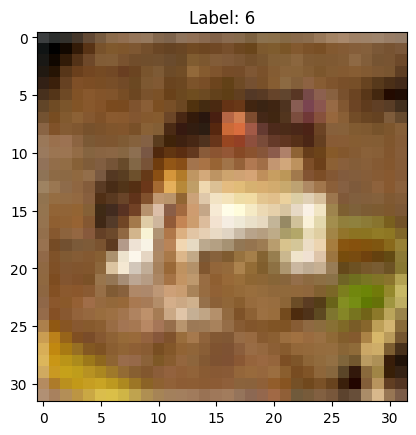

In [23]:
image_np = image.permute(1, 2, 0)
plt.imshow(image_np)
plt.title(f"Label: {label}")
plt.show()

In [24]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]
print(classes[label])


frog


In [25]:
import torch.nn as nn

conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=6,
    kernel_size=5
)

In [26]:
print(conv1)

Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))


In [29]:
image_batch = image.unsqueeze(0)
print(image_batch.shape)
output = conv1(image_batch)
print(output.shape)

torch.Size([1, 3, 32, 32])
torch.Size([1, 6, 28, 28])


In [30]:
feature_maps = output.squeeze(0)
print(feature_maps.shape)

torch.Size([6, 28, 28])


In [31]:
first_map = feature_maps[0]
print(first_map.shape)

torch.Size([28, 28])


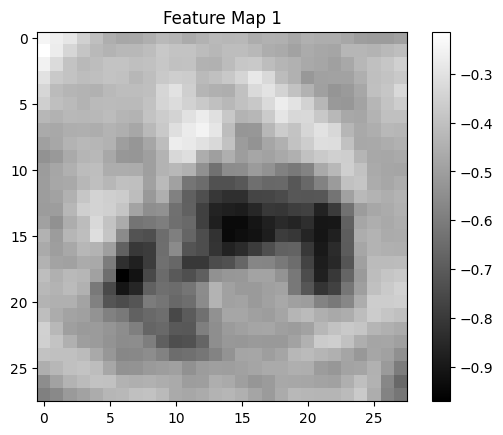

In [32]:
import matplotlib.pyplot as plt

plt.imshow(first_map.detach().numpy(), cmap='gray')
plt.title("Feature Map 1")
plt.colorbar()
plt.show()

In [35]:
output = conv1(image_batch)
print(output.shape)
feature_maps = output.squeeze(0)
print(feature_maps.shape)

torch.Size([1, 6, 28, 28])
torch.Size([6, 28, 28])


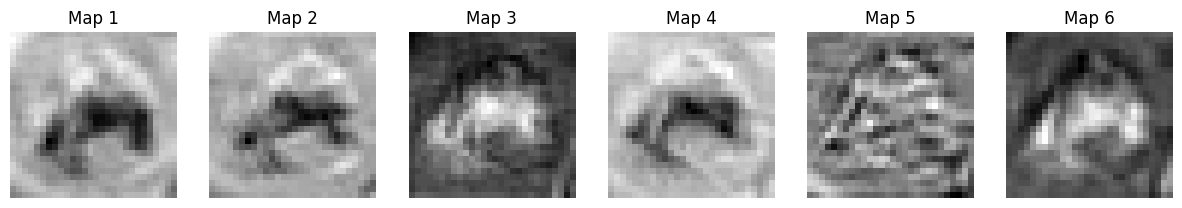

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i in range(6):
    axes[i].imshow(feature_maps[i].detach().numpy(), cmap='gray')
    axes[i].set_title(f"Map {i+1}")
    axes[i].axis("off")

plt.show()

In [37]:
pool = nn.MaxPool2d(kernel_size=2, stride=2)

pooled_output = pool(output)
print(pooled_output.shape)

torch.Size([1, 6, 14, 14])


In [38]:
import torch.nn as nn

conv = nn.Conv2d(3, 6, kernel_size=5)
relu = nn.ReLU()
pool = nn.MaxPool2d(kernel_size=2, stride=2)

In [39]:
x = image.unsqueeze(0)

x = conv(x)
print("After Conv:", x.shape)

x = relu(x)
print("After ReLU:", x.shape)

x = pool(x)
print("After Pool:", x.shape)

After Conv: torch.Size([1, 6, 28, 28])
After ReLU: torch.Size([1, 6, 28, 28])
After Pool: torch.Size([1, 6, 14, 14])
